# Final Course Project: Survival Prediction and Model Comparison

Oded Katz — 211862693 &nbsp;&nbsp;|&nbsp;&nbsp; Diana Morgan — 336472261


| Notebook section | Assignment item |
|---|---|
| 0. Setup and preprocessing | shared data preparation |
| 1. Recap of Project Assignment 1 | item 1 |
| 2. Recap of Project Assignment 2 | item 2 |
| 3. Research questions | item 3 |
| 4. Train-test split | item 4 |
| 5. Refitting the selected Cox model | item 5 |
| 6. One-year survival prediction (Cox) | item 6 |
| 7. Additional survival models (RSF, DeepSurv, Cox-Time) | item 7 |
| 8. Comparison of one-year prediction curves | item 8 |
| 9. Test-set model comparison | item 9 |
| 10. Additional analyses | item 10 |
| 11. Final discussion | item 11 |

---
## 0. Setup and preprocessing

We start from the dataset PA1 produced, where missing values were filled in with the median of each continuous covariate. No categorical covariate had missing values.

Two variables are built here because Section 2 onwards needs them:

* `n_comorbidities` — how many of the nine comorbidity indicators a patient has, grouped into `cat_comorbidities` with levels 0-1 (reference), 2-3 and 4+.
* `delta_BUN` — `BUN_discharge` minus `BUN_admission`, i.e. how far the blood urea nitrogen moved during the stay.


In [89]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter

# ---- global configuration -------------------------------------------------
SEED = 42                      
np.random.seed(SEED)

DATA_PATH = os.path.join("..", "PA1", "imputed_data.csv")
FIG_DIR = "figures"
TAB_DIR = "tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

TIME_COL = "time_discharge_to_death_MONTHS"
EVENT_COL = "death"
HORIZON = 12.0                 
MAX_FOLLOWUP = 36.0           

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

In [90]:
df = pd.read_csv(DATA_PATH)

df = df.drop(columns=[c for c in ["survival_status"] if c in df.columns])

# ---- comorbidity burden (PA2) ---------------------------------------------
COMORBIDITY_COLS = ["diabetes", "hypertension", "COPD", "PVD",
                    "CKD", "IHD", "AF", "VHD", "PHTN"]

df["n_comorbidities"] = df[COMORBIDITY_COLS].sum(axis=1)
df["cat_comorbidities"] = pd.cut(
    df["n_comorbidities"],
    bins=[0, 1, 3, np.inf],
    include_lowest=True,
    labels=["0-1", "2-3", "4+"],
)

# ---- change in BUN during hospitalisation (PA2) ---------------------------
df["delta_BUN"] = df["BUN_discharge"] - df["BUN_admission"]

print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print(f"Any remaining missing values: {bool(df.isna().any().any())}")
df.head()

Rows: 3961   Columns: 30
Any remaining missing values: False


,gender_0male_1female,age_YEARS,diabetes,hypertension,COPD,PVD,CKD,IHD,AF,VHD,PHTN,BNP,BUN_admission,BUN_discharge,creatinine_admission,creatinine_discharge,GFR_admission,GFR_discharge,WBC,sodium,RDW,platelets,bilirubin,potassium,length_of_stay_DAYS,time_discharge_to_death_MONTHS,death,n_comorbidities,cat_comorbidities,delta_BUN
0,0,48.85803,0,0,0,0,0,0,0,0,0,1258.04,66.0,65.0,1.10,1.10,78.960885,80.768963,9.40,138.00,21.3,178.0,1.090,3.9,0.456785,5.000000,1,0,0-1,-1.0
1,0,49.67481,0,0,0,0,0,0,0,0,0,291.55,46.0,46.0,1.53,1.56,55.584022,54.435869,4.40,127.42,21.6,114.0,5.765,4.8,0.245513,0.700000,1,0,0-1,0.0
2,0,85.35892,0,0,0,0,0,0,0,0,0,1473.78,16.0,17.0,1.43,1.27,41.135539,48.993978,10.50,130.00,17.2,289.0,0.520,4.0,1.632458,8.033333,1,0,0-1,1.0
3,0,52.80388,0,0,0,0,0,0,0,0,0,940.32,28.3,30.0,1.43,1.13,55.718423,75.232868,8.50,135.00,13.3,188.0,0.550,6.1,5.921769,0.033333,1,0,0-1,1.7
4,0,67.30150,0,0,0,0,0,0,0,0,0,2625.98,59.0,28.0,2.65,2.32,26.914463,31.042884,13.17,136.40,14.7,274.0,0.500,5.3,17.214475,20.433333,0,0,0-1,-31.0


---
# 1. Brief recap of Project Assignment 1

PA1 constituted the exploratory analysis of the data: we characterized the covariates, addressed missing values, defined the survival outcome and censoring mechanism, and examined the Kaplan–Meier curves that informed the formulation of our research questions.

## 1.1 Dataset and survival outcome

The data is synthetic dataset 2. Every row is a patient admitted with acute decompensated heart failure who made it out of hospital alive. There are 27 columns: 25 covariates, the survival time, and the event indicator.

* **Event.** Death from any cause, `death = 1`.
* **Survival time.** `time_discharge_to_death_MONTHS`, from discharge to death or to the end of follow-up, in months.
* **Censoring.** Follow-up ends at 36 months. Patients with `death = 0` are right-censored, meaning that they are known to have survived until their last recorded follow-up time, while their status thereafter is unknown. Approximately two thirds of censored patients are censored at 36 months; the remainder leave follow-up earlier, with censoring times distributed relatively evenly across the observation period. We assume that censoring is independent of survival time conditional on the observed covariates.



## 1.2 Sample size, events and censoring

In [91]:
n_total = len(df)
n_events = int((df[EVENT_COL] == 1).sum())
n_censored = int((df[EVENT_COL] == 0).sum())

followup = df[TIME_COL]
is_censored = df[EVENT_COL] == 0

censored_at_end = int((is_censored & (followup >= MAX_FOLLOWUP)).sum())
censored_early = int((is_censored & (followup < MAX_FOLLOWUP)).sum())
early_times = followup[is_censored & (followup < MAX_FOLLOWUP)]

sample_summary = pd.DataFrame(
    {
        "n": [n_total, n_events, n_censored, censored_at_end, censored_early],
        "% of cohort": [
            100.0,
            100 * n_events / n_total,
            100 * n_censored / n_total,
            100 * censored_at_end / n_total,
            100 * censored_early / n_total,
        ],
    },
    index=[
        "Patients (sample size)",
        "Observed deaths (death = 1)",
        "Censored observations (death = 0)",
        "  of which administratively censored at 36 months",
        "  of which lost to follow-up before 36 months",
    ],
).round(2)

n_events_by_horizon = int(((df[EVENT_COL] == 1) & (followup <= HORIZON)).sum())
n_censored_pre_horizon = int((is_censored & (followup < HORIZON)).sum())

print("Follow-up time (months): "
      f"median = {followup.median():.2f}, "
      f"IQR = [{followup.quantile(.25):.2f}, {followup.quantile(.75):.2f}], "
      f"range = [{followup.min():.2f}, {followup.max():.2f}]")
print(f"Total person-months of follow-up: {followup.sum():,.0f}")
print(f"Censoring times of the {censored_early} lost to follow-up before {MAX_FOLLOWUP:.0f} months: "
      f"median = {early_times.median():.2f}, "
      f"IQR = [{early_times.quantile(.25):.2f}, {early_times.quantile(.75):.2f}]")
print(f"By the {HORIZON:.0f}-month horizon: {n_events_by_horizon} deaths, "
      f"{n_censored_pre_horizon} censored beforehand")
sample_summary

Follow-up time (months): median = 25.60, IQR = [8.83, 36.00], range = [0.00, 36.00]
Total person-months of follow-up: 88,266
Censoring times of the 809 lost to follow-up before 36 months: median = 16.47, IQR = [7.93, 25.37]
By the 12-month horizon: 947 deaths, 328 censored beforehand


,n,% of cohort
Patients (sample size),3961,100.00
Observed deaths (death = 1),1679,42.39
Censored observations (death = 0),2282,57.61
of which administratively censored at 36 months,1473,37.19
of which lost to follow-up before 36 months,809,20.42


In [92]:
sample_summary.to_csv(os.path.join(TAB_DIR, "table1a_sample_size.csv"))

**Table 1a**. There are 3,961 patients. 1,679 of them (42.4%) died during follow-up and 2,282 (57.6%) were censored. Of those censored, 1,473 reach the 36-month cutoff; the other 809 drop out earlier, at a median of 16.5 months. Median follow-up is 25.6 months, and the cohort contributes about 88,000 person-months in total.

## 1.3 Covariates

The 25 covariates group into five blocks: demographics, the nine comorbidity indicators, labs taken on admission, labs taken on discharge, and length of stay. Table 1 summarises them across the whole cohort, continuous variables as median [Q1, Q3] and binary ones as n (%).



In [93]:
LABELS = {
    "gender_0male_1female": "Female sex",
    "age_YEARS": "Age (years)",
    "diabetes": "Diabetes",
    "hypertension": "Hypertension",
    "COPD": "COPD",
    "PVD": "Peripheral vascular disease",
    "CKD": "Chronic kidney disease",
    "IHD": "Ischaemic heart disease",
    "AF": "Atrial fibrillation",
    "VHD": "Valvular heart disease",
    "PHTN": "Pulmonary hypertension",
    "BNP": "BNP, admission (pg/mL)",
    "BUN_admission": "BUN, admission (mg/dL)",
    "creatinine_admission": "Creatinine, admission (mg/dL)",
    "GFR_admission": "GFR, admission (mL/min/1.73m2)",
    "BUN_discharge": "BUN, discharge (mg/dL)",
    "creatinine_discharge": "Creatinine, discharge (mg/dL)",
    "GFR_discharge": "GFR, discharge (mL/min/1.73m2)",
    "WBC": "White blood cells (1000/uL)",
    "sodium": "Sodium (mEq/L)",
    "RDW": "Red cell distribution width (%)",
    "platelets": "Platelets (1000/uL)",
    "bilirubin": "Bilirubin (mg/dL)",
    "potassium": "Potassium (mEq/L)",
    "length_of_stay_DAYS": "Length of stay (days)",
}

BLOCKS = [
    ("Demographics", ["age_YEARS", "gender_0male_1female"]),
    ("Comorbidities (as recorded in PA1)", COMORBIDITY_COLS),
    ("Laboratory values on admission",
     ["BNP", "BUN_admission", "creatinine_admission", "GFR_admission"]),
    ("Laboratory values on discharge",
     ["BUN_discharge", "creatinine_discharge", "GFR_discharge"]),
    ("Other laboratory values",
     ["WBC", "sodium", "RDW", "platelets", "bilirubin", "potassium"]),
    ("Hospitalisation", ["length_of_stay_DAYS"]),
]

BINARY_COLS = ["gender_0male_1female"] + COMORBIDITY_COLS


def _continuous(series):
    return f"{series.median():.2f} [{series.quantile(.25):.2f}, {series.quantile(.75):.2f}]"


def _count(mask, n):
    k = int(mask.sum())
    return f"{k} ({100 * k / n:.1f}%)"


def build_covariate_table(data):
    n = len(data)
    rows = []
    for block, cols in BLOCKS:
        rows.append([f"[{block}]", "", ""])
        for col in cols:
            label = LABELS.get(col, col)
            if col in BINARY_COLS:
                rows.append([label, "n (%)", _count(data[col] == 1, n)])
            elif str(data[col].dtype) == "category":
                rows.append([label, "n (%)", ""])
                for level in data[col].cat.categories:
                    rows.append([f"    {level}", "", _count(data[col] == level, n)])
            else:
                rows.append([label, "median [Q1, Q3]", _continuous(data[col])])
    return pd.DataFrame(rows, columns=["Covariate", "Summary", f"All patients (n = {n})"])


table_one = build_covariate_table(df)
table_one.to_csv(os.path.join(TAB_DIR, "table1_covariates.csv"), index=False)
table_one.style.hide(axis="index")

Covariate,Summary,All patients (n = 3961)
[Demographics],,
Age (years),"median [Q1, Q3]","76.18 [66.85, 83.24]"
Female sex,n (%),1842 (46.5%)
[Comorbidities (as recorded in PA1)],,
Diabetes,n (%),2147 (54.2%)
Hypertension,n (%),3432 (86.6%)
COPD,n (%),405 (10.2%)
Peripheral vascular disease,n (%),367 (9.3%)
Chronic kidney disease,n (%),805 (20.3%)
Ischaemic heart disease,n (%),2484 (62.7%)


**Table 1**. Median age is 76 and 46.5% are women. The nine comorbidity columns are binary flags for conditions the patient already had before this admission, and most patients have several set at once: hypertension in 86.6%, ischaemic heart disease in 62.7%, diabetes in 54.2%, atrial fibrillation in 40.6%.

Median BUN goes from 25 mg/dL on admission to 28 at discharge. Stays are short, median 5.1 days. 


## 1.4 Overall Kaplan-Meier survival curve

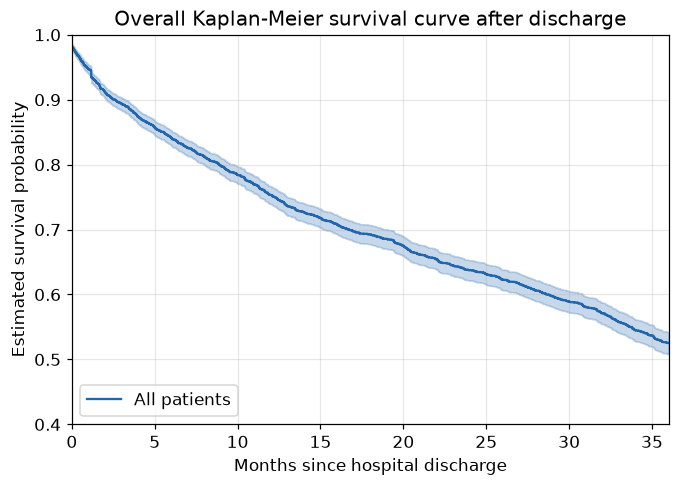

In [94]:
km = KaplanMeierFitter(label="All patients")
km.fit(durations=df[TIME_COL], event_observed=df[EVENT_COL])

fig, ax = plt.subplots(figsize=(7.0, 4.6))
km.plot_survival_function(ax=ax, ci_show=True, color="#2166ac")
ax.set_xlabel("Months since hospital discharge")
ax.set_ylabel("Estimated survival probability")
ax.set_title("Overall Kaplan-Meier survival curve after discharge")
ax.set_xlim(0, MAX_FOLLOWUP)
ax.set_ylim(0.4, 1.0)
ax.legend(loc="lower left")
fig.savefig(os.path.join(FIG_DIR, "fig1_km_overall.png"))
plt.show()

Figure 1. Survival falls steadily across the three years, from 1 at discharge down to about 0.53 at 36 months. The drop is fastest in the first few months and then settles into a roughly straight line. Around three quarters of the cohort are still alive at one year.

## 1.5 Stratified Kaplan-Meier curves

PA1 stratified the survival curves by sex and by diabetes. Both are reproduced below, each panel with a log-rank test for equality of the two curves.

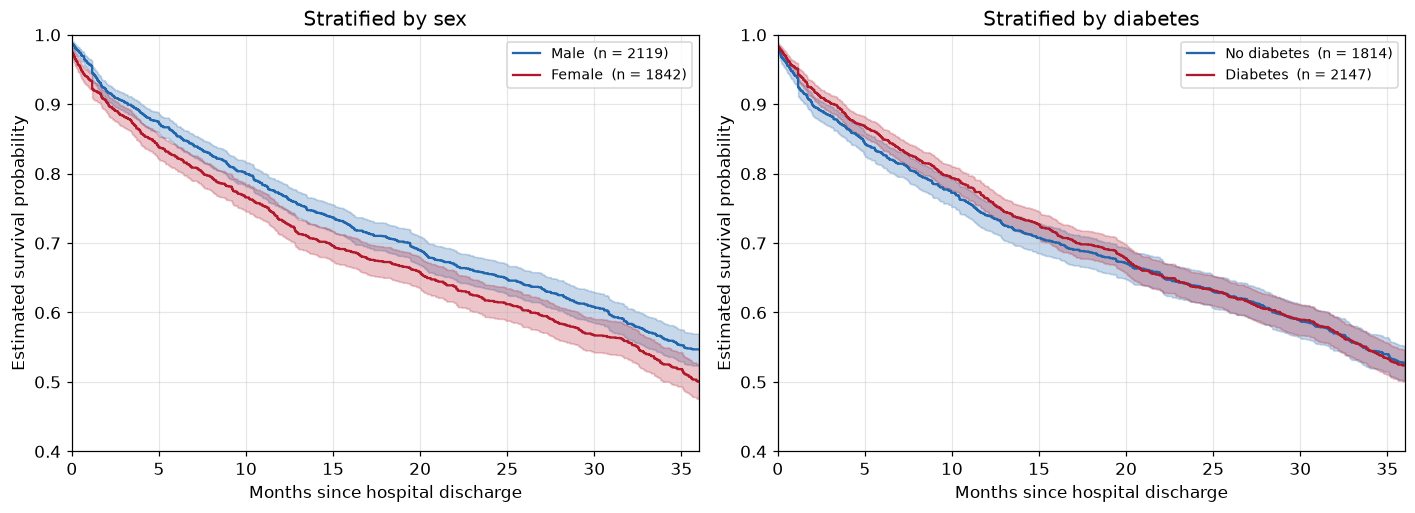

Sex        S(12)|Male = 0.770  S(12)|Female = 0.733
Diabetes   S(12)|No diabetes = 0.740  S(12)|Diabetes = 0.764


In [95]:
PALETTE = ["#2166ac", "#b2182b", "#1b7837"]


def plot_km_strata(ax, data, groups, title, ylim=(0.4, 1.0)):
    # groups: list of (label, boolean mask)
    surv_at_horizon = {}
    for (label, mask), color in zip(groups, PALETTE):
        sub = data[mask]
        f = KaplanMeierFitter(label=f"{label}  (n = {int(mask.sum())})")
        f.fit(durations=sub[TIME_COL], event_observed=sub[EVENT_COL])
        f.plot_survival_function(ax=ax, ci_show=True, color=color)
        surv_at_horizon[label] = float(f.survival_function_at_times([HORIZON]).iloc[0])

    ax.set_xlabel("Months since hospital discharge")
    ax.set_ylabel("Estimated survival probability")
    ax.set_title(title)
    ax.set_xlim(0, MAX_FOLLOWUP)
    ax.set_ylim(*ylim)
    ax.legend(loc="upper right", fontsize=9)
    return surv_at_horizon


fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

s_sex = plot_km_strata(
    axes[0], df,
    [("Male", df["gender_0male_1female"] == 0),
     ("Female", df["gender_0male_1female"] == 1)],
    "Stratified by sex",
)

s_dm = plot_km_strata(
    axes[1], df,
    [("No diabetes", df["diabetes"] == 0),
     ("Diabetes", df["diabetes"] == 1)],
    "Stratified by diabetes",
)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig2_km_stratified.png"))
plt.show()

for name, s in [("Sex", s_sex), ("Diabetes", s_dm)]:
    print(f"{name:10s} " + "  ".join(f"S(12)|{k} = {v:.3f}" for k, v in s.items()))

Figure 2. PA1's two stratifications.

* **Sex.** The male curve sits a little above the female one for the whole three years, 0.77 against 0.73 at one year. The confidence bands overlap over almost all of the follow-up, so the two curves are not clearly separated. 
* **Diabetes.** The two curves lie on top of each other and the bands overlap everywhere.

Neither split separates the cohort usefully. 

Neither of PA1's splits separates the cohort. Two that do are age and the BUN measured at discharge, both split at their medians.

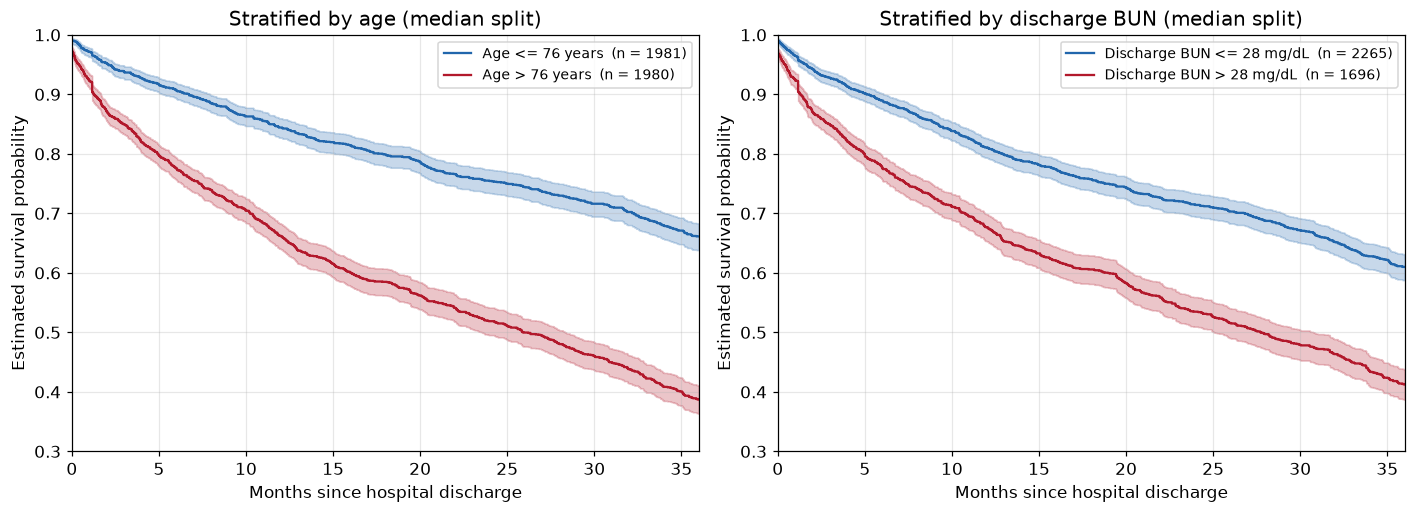

Age            S(12)|Age <= 76 years = 0.844  S(12)|Age > 76 years = 0.661
Discharge BUN  S(12)|Discharge BUN <= 28 mg/dL = 0.810  S(12)|Discharge BUN > 28 mg/dL = 0.676


In [96]:
age_median = df["age_YEARS"].median()
bun_median = df["BUN_discharge"].median()

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

s_age = plot_km_strata(
    axes[0], df,
    [(f"Age <= {age_median:.0f} years", df["age_YEARS"] <= age_median),
     (f"Age > {age_median:.0f} years", df["age_YEARS"] > age_median)],
    "Stratified by age (median split)",
    ylim=(0.3, 1.0),
)

s_bun = plot_km_strata(
    axes[1], df,
    [(f"Discharge BUN <= {bun_median:.0f} mg/dL", df["BUN_discharge"] <= bun_median),
     (f"Discharge BUN > {bun_median:.0f} mg/dL", df["BUN_discharge"] > bun_median)],
    "Stratified by discharge BUN (median split)",
    ylim=(0.3, 1.0),
)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig3_km_age_bun.png"))
plt.show()

for name, s in [("Age", s_age), ("Discharge BUN", s_bun)]:
    print(f"{name:14s} " + "  ".join(f"S(12)|{k} = {v:.3f}" for k, v in s.items()))

Figure 3. Both splits open a gap early and hold it for the whole three years, and in both cases the confidence bands stay clear of each other from the first month to the last.

* **Age.** Above the median of 76 years, one-year survival is 0.66 against 0.84 below it.
* **Discharge BUN.** Above the median of 28 mg/dL, one-year survival is 0.68 against 0.81.

Compare Figure 2, where sex moves one-year survival by 0.04 with overlapping bands and diabetes moves it by nothing at all. These two move it by 0.18 and 0.13, with no overlap anywhere. 

## 1.6 Research questions motivating the analysis

PA1 finished with a preliminary Cox model on all 25 covariates. Age, RDW, sodium, BUN on both admission and discharge, BNP, length of stay, COPD, bilirubin and potassium came out significant; the demographics and most of the comorbidity indicators did not. Together with the curves above, that gave us three questions:

> RQ1. Does the change in BUN between admission and discharge tell us anything about post-discharge survival that the discharge BUN level does not already?
>
> RQ2. Are there interactions between covariates that matter for survival?
>
> RQ3. How well can we predict a patient's survival at the moment they are discharged, using only what is known then?



---
# 2. Brief recap of Project Assignment 2

PA2 moved from description to modelling. It replaced the nine comorbidity flags with the burden variable, fitted a Cox proportional hazards model, tested whether the change in BUN during the stay adds anything on top of the discharge value, checked the proportional hazards assumption, and compared the Cox model against a log-normal AFT model for one-year prediction. 

## 2.1 The selected model

The model PA2 settled on has fifteen terms: sex, age, comorbidity burden (0-1 as the reference level, 2-3, 4+), length of stay, BUN at discharge, creatinine at discharge, GFR at discharge, BNP, white blood cells, sodium, RDW, platelets, bilirubin, potassium, and `delta_BUN`.

In [97]:
from lifelines import CoxPHFitter

PA2_FORMULA = ("gender_0male_1female + age_YEARS + C(cat_comorbidities) + "
               "length_of_stay_DAYS + BUN_discharge + creatinine_discharge + GFR_discharge + "
               "BNP + WBC + sodium + RDW + platelets + bilirubin + potassium + delta_BUN")

cox_pa2 = CoxPHFitter().fit(df, duration_col=TIME_COL, event_col=EVENT_COL, formula=PA2_FORMULA)
print(f"Concordance: {cox_pa2.concordance_index_:.4f}")

pa2_hr = (cox_pa2.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
          .round(4).sort_values("p"))
pa2_hr.to_csv(os.path.join(TAB_DIR, "table2_pa2_cox.csv"))
pa2_hr

Concordance: 0.6943


,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
age_YEARS,1.0438,1.0382,1.0495,0.0000
BUN_discharge,1.0213,1.0176,1.0249,0.0000
sodium,0.9728,0.9627,0.9831,0.0000
BNP,1.0002,1.0001,1.0002,0.0000
delta_BUN,0.9903,0.9867,0.9938,0.0000
RDW,1.1204,1.0903,1.1514,0.0000
length_of_stay_DAYS,1.0094,1.0037,1.0151,0.0011
bilirubin,1.1208,1.0068,1.2477,0.0372
potassium,0.9141,0.8397,0.9951,0.0382


**Table 2**. Nine terms are significant at the 5% level : **Age, BUN at discharge, sodium, BNP, delta BUN, RDW, length of stay, bilirubin, and potassium**. Age is 1.044 per year, so a ten-year gap multiplies the hazard by about 1.5. Discharge BUN is 1.021 per mg/dL, RDW 1.120 per unit, bilirubin 1.121, length of stay 1.009 per day. Sodium at 0.973 and potassium at 0.914 run the other way. BNP is 1.0002 per pg/mL, which is not negligible as the variable runs into the thousands.

Neither comorbidity burden level is significant: 0.89 for 2-3 against the 0-1 reference, 0.99 for 4+. Sex, white blood cells, discharge creatinine, discharge GFR and platelets are insignifficant as well. 


## 2.2 Does the change in BUN add anything?

Yes, and thus `delta_BUN` is included in the model above. PA2 compared the fit with and without it using a likelihood-ratio test and got 27.63 on 1 degree of freedom, p = 1.5e-07, so the change in BUN over the stay carries information the discharge value alone does not. 

## 2.3 Proportional hazards diagnostics

The Cox model assumes each covariate's hazard ratio is constant over follow-up. PA2 checked this with the Schoenfeld residual test using a rank transform of time. The cell below repeats that test on the selected model.

In [98]:
from lifelines.statistics import proportional_hazard_test

ph_test = proportional_hazard_test(cox_pa2, df, time_transform="rank")
ph_summary = ph_test.summary[["test_statistic", "p"]].round(4).sort_values("p")
ph_summary.to_csv(os.path.join(TAB_DIR, "table4_ph_test.csv"))

print(f"Covariates with p < 0.05: {int((ph_summary['p'] < 0.05).sum())} of {len(ph_summary)}")
ph_summary

Covariates with p < 0.05: 2 of 16


,test_statistic,p
BUN_discharge,4.3917,0.0361
length_of_stay_DAYS,3.9114,0.0480
creatinine_discharge,2.7398,0.0979
C(cat_comorbidities)[T.4+],2.7004,0.1003
bilirubin,2.4538,0.1172
sodium,1.6433,0.1999
C(cat_comorbidities)[T.2-3],1.3876,0.2388
gender_0male_1female,1.2686,0.2600
age_YEARS,1.0640,0.3023
GFR_discharge,0.8278,0.3629


**Table 4**. Two terms come out under 0.05: discharge BUN at 0.036 and length of stay at 0.048. Both are only just under. The other fourteen are safe.

Overall, the formal tests suggest mild possible violations, but the graphical evidence (showed in PA2) is not very clear or severe.

## 2.4 Cox against the log-normal AFT model

PA2 also fitted a log-normal accelerated failure time model on the same covariates. An AFT model works on survival time rather than on the hazard, so the signs read the other way round: a positive coefficient means longer survival.

The two models agreed on direction throughout. Age, discharge BUN, RDW, bilirubin and length of stay all came out negative in the AFT fit, matching hazard ratios above 1 in the Cox model. Sodium came out positive, matching its hazard ratio below 1. `delta_BUN` came out positive too, matching the 0.990 discussed above.


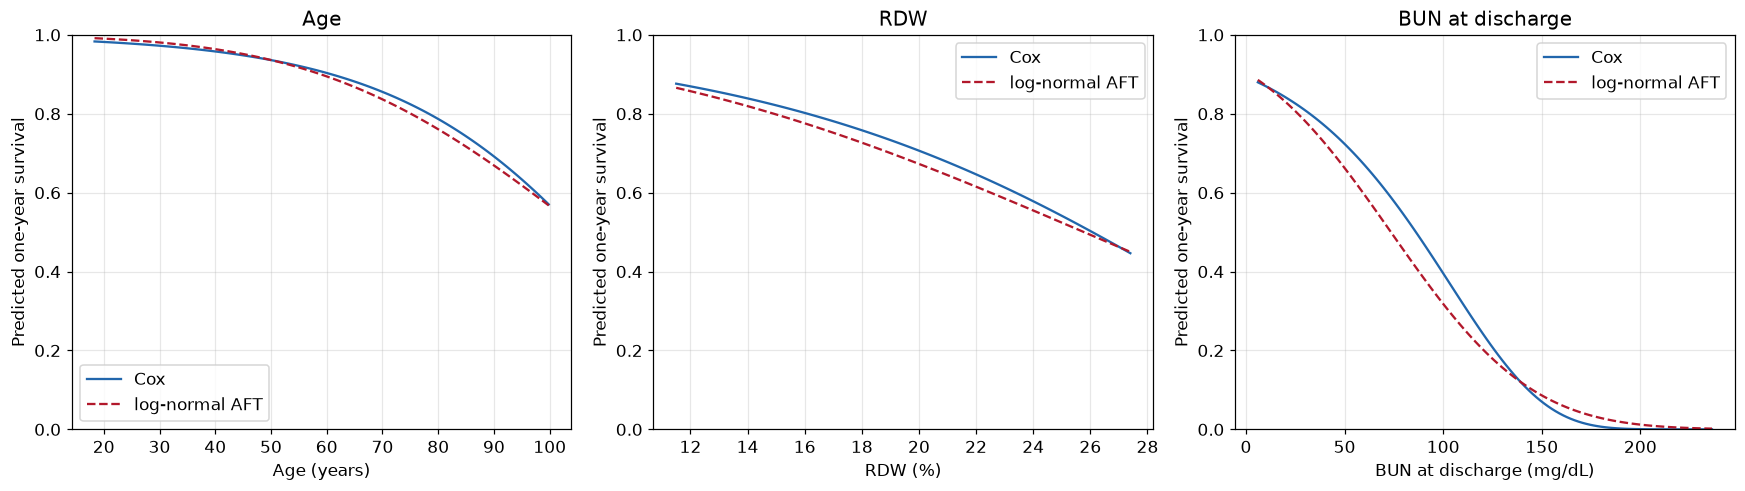

                     representative value
gender_0male_1female                  0.0
age_YEARS                        76.18272
cat_comorbidities                     2-3
length_of_stay_DAYS              5.128474
BUN_discharge                        28.0
creatinine_discharge                 1.23
GFR_discharge                   50.433085
BNP                                 778.1
WBC                                  8.92
sodium                              138.0
RDW                                  15.3
platelets                           225.0
bilirubin                             0.6
potassium                             4.3
delta_BUN                             3.0


In [99]:
from lifelines import LogNormalAFTFitter

# the log-normal AFT model needs strictly positive times
aft_df = df.copy()
aft_df.loc[aft_df[TIME_COL] <= 0, TIME_COL] = 0.01
aft_pa2 = LogNormalAFTFitter().fit(aft_df, duration_col=TIME_COL, event_col=EVENT_COL,
                                   formula=PA2_FORMULA)

MODEL_VARS = ["gender_0male_1female", "age_YEARS", "cat_comorbidities", "length_of_stay_DAYS",
              "BUN_discharge", "creatinine_discharge", "GFR_discharge", "BNP", "WBC", "sodium",
              "RDW", "platelets", "bilirubin", "potassium", "delta_BUN"]


def representative_row(data, columns):
    # median for continuous covariates, most common level for categorical ones
    row = {}
    for col in columns:
        if pd.api.types.is_numeric_dtype(data[col]):
            row[col] = [data[col].median()]
        else:
            row[col] = [data[col].mode().iloc[0]]
    return pd.DataFrame(row)


def one_year_curve(model, covariate, grid, base):
    rows = pd.concat([base.assign(**{covariate: v}) for v in grid], ignore_index=True)
    return model.predict_survival_function(rows, times=[HORIZON]).iloc[0].values


base_row = representative_row(df, MODEL_VARS)

fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))
for ax, cov, label in zip(axes,
                          ["age_YEARS", "RDW", "BUN_discharge"],
                          ["Age (years)", "RDW (%)", "BUN at discharge (mg/dL)"]):
    grid = np.linspace(df[cov].min(), df[cov].max(), 120)
    ax.plot(grid, one_year_curve(cox_pa2, cov, grid, base_row), color="#2166ac", label="Cox")
    ax.plot(grid, one_year_curve(aft_pa2, cov, grid, base_row), color="#b2182b",
            linestyle="--", label="log-normal AFT")
    ax.set_xlabel(label)
    ax.set_ylabel("Predicted one-year survival")
    ax.set_title(label.split(" (")[0])
    ax.set_ylim(0, 1)
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig4_cox_vs_aft.png"))
plt.show()

print(base_row.T.rename(columns={0: "representative value"}).to_string())

Figure 4. Each panel sweeps one covariate across its observed range and holds everything else at the representative values printed under the figure: the median for continuous covariates, the most common level for comorbidity burden, which is 2-3.

For age the two curves are almost indistinguishable. For RDW they separate a little, the AFT model predicting slightly lower across the middle of the range, and they meet again at the top. Discharge BUN shows the widest gap: the AFT curve falls faster between roughly 20 and 120 mg/dL, then flattens and crosses above the Cox curve in the tail. Worth noting that the BUN axis runs to 236 mg/dL because that is the observed maximum, but three quarters of patients sit below 39, so nearly all the data lives in the left fifth of that panel.


---
# 3. Research questions

## 3.1 The questions from Project Assignment 1

Project Assignment 1 closed with three questions:

> RQ1 (PA1). Does the difference between BUN on admission and BUN on discharge have a significant effect on the survival outcome?
>
> RQ2 (PA1). Are there covariate interactions with a significant effect on the survival outcome?
>
> RQ3 (PA1). How accurately can a patient's survival outcome be predicted at hospital discharge?

The first question has been answered. PA2 added `delta_BUN` to the Cox model and the likelihood-ratio test was significant, 27.63 on one degree of freedom with p = 1.5e-07, so the change in BUN over the admission does carry information beyond the discharge value alone.

The second question was never addressed. Neither assignment fitted an interaction term. As originally phrased the question also does not say which interactions to look for, and with fifteen covariates there are 105 pairwise terms, so testing all of them would produce significant results by chance alone. We keep the question, but narrow it to two interactions chosen in advance. Section 3.2 sets them out.

The third question was not addressed either. PA1 and PA2 both fitted models to the full dataset and reported in-sample summaries. Neither held any data out, so neither produced an honest estimate of how well survival can actually be predicted.

## 3.2 Final research questions

The three questions below guide the rest of the project. Each descends from one of the PA1 questions, and each is answered by analyses the assignment already requires.

> **RQ1.** How accurately can one-year survival be predicted from the information available at discharge, and do the more flexible models predict better than the Cox model?

This is PA1's third question made specific. Section 4 splits the data into training and test sets. Sections 5 and 7 fit the Cox model, a random survival forest, DeepSurv and Cox-Time on the training set. Section 9 compares them. 

> **RQ2.** Where the more flexible models differ from the Cox model, which of the Cox model's assumptions is responsible?

The Cox model assumes three separate things: that each covariate acts linearly on the log hazard, that covariate effects add together without interacting, and that hazard ratios stay constant over follow-up. The three additional models give up different combinations of these. DeepSurv replaces the linear predictor with a neural network, so it allows non-linear effects and interactions, but it keeps hazards proportional. Cox-Time lets the risk score depend on time as well, so hazard ratios need not be constant. The random survival forest assumes none of the three, since it splits the data recursively and estimates a separate cumulative hazard in each terminal node.


Section 2.3 gives one concrete reason to ask. The proportional hazards assumption came out borderline for discharge BUN, p = 0.036, and for length of stay, p = 0.048. The prediction curves in Section 8 will show whether the flexible models see age, RDW and discharge BUN the same way the Cox model does, and the test-set results in Section 9 will show whether any of the differences improve prediction.


> **RQ3.** Do the two interactions specified below improve on the additive Cox model?

This is PA1's second question, narrowed to something that can be answered. Rather than searching over all 105 pairwise terms, we fix two in advance and give the reason for each.

The first is between `delta_BUN` and discharge BUN. The change and the level are closely tied, since `delta_BUN` is discharge minus admission, and the same change plausibly means different things depending on the level the patient reached. A rise of 10 mg/dL in someone leaving at 25 is not the same situation as the same rise in someone leaving at 60, yet the additive model assigns both the same effect. An interaction lets the effect of the change depend on the discharge level, which is the natural way to ask whether the two carry information jointly rather than separately.

The second is between age and discharge BUN, the two strongest predictors in Table 2. Whether reduced kidney clearance carries the same risk at 60 as it does at 85 is a question with a clear reading either way.

Each interaction is a single term added to the Section 5 model and tested by a likelihood-ratio test on the training data, in Section 10. Two tests chosen in advance keep multiplicity to a footnote rather than a problem.